# 🎬 Netflix Movie Data Analysis — Exploratory Data Analysis (EDA)

## 📌 Objective
The goal of this project is to perform Exploratory Data Analysis (EDA) on a movie dataset to uncover patterns, trends, and insights related to:

- Movie genres
- Popularity
- Vote averages
- Release trends over the years

This analysis simulates how a data analyst might explore content data to support decision-making for a streaming platform like Netflix.

---

## 📂 Dataset Overview

The dataset contains information about movies, including:

- Title
- Genre
- Release Date
- Popularity Score
- Vote Average
- Vote Count

---

## 🎯 Key Questions Explored

1. What is the most frequent genre of movies?
2. Which movie has the highest vote average?
3. Which movie has the highest popularity? What is its genre?
4. Which movie has the lowest popularity? What is its genre?
5. Which year has the highest number of movie releases?

---

## 🛠 Tools Used

- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn

In [27]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv(
    "mymoviedb.csv",
    engine="python",
    quotechar='"',
    escapechar='\\',
    encoding="latin1"
)

## 🧹 Data Cleaning

Before analysis, the dataset needs to be cleaned to ensure accuracy.

Steps performed:

- Removed irrelevant columns that do not contribute to analysis
- Checked for duplicate records
- Handled missing values
- Converted date columns into proper datetime format
- Extracted release year for time-based analysis

Clean data is essential for producing reliable insights.

In [28]:
df.duplicated().sum()

np.int64(0)

In [29]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9827 entries, 0 to 9826
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Release_Date       9827 non-null   str    
 1   Title              9827 non-null   str    
 2   Overview           9827 non-null   str    
 3   Popularity         9826 non-null   float64
 4   Vote_Count         9826 non-null   float64
 5   Vote_Average       9826 non-null   float64
 6   Original_Language  9826 non-null   str    
 7   Genre              9826 non-null   str    
 8   Poster_Url         9826 non-null   str    
dtypes: float64(3), str(6)
memory usage: 691.1 KB


In [31]:
todrop=['Overview','Original_Language','Poster_Url']
df.drop(todrop,axis=1,inplace=True)
df.head()

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre
0,2021-12-15,Spider-Man: No Way Home,5083.954,8940.0,8.3,"Action, Adventure, Science Fiction"
1,2022-03-01,The Batman,3827.658,1151.0,8.1,"Crime, Mystery, Thriller"
2,2022-02-25,No Exit,2618.087,122.0,6.3,Thriller
3,2021-11-24,Encanto,2402.201,5076.0,7.7,"Animation, Comedy, Family, Fantasy"
4,2021-12-22,The King's Man,1895.511,1793.0,7.0,"Action, Adventure, Thriller, War"


In [32]:
df.isna().sum()
df.dropna(inplace=True)
df.info()

<class 'pandas.DataFrame'>
Index: 9826 entries, 0 to 9826
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Release_Date  9826 non-null   str    
 1   Title         9826 non-null   str    
 2   Popularity    9826 non-null   float64
 3   Vote_Count    9826 non-null   float64
 4   Vote_Average  9826 non-null   float64
 5   Genre         9826 non-null   str    
dtypes: float64(3), str(3)
memory usage: 537.4 KB


## 📅 Release Year Extraction

The release date is converted into datetime format, and only the year is extracted.

This allows us to analyze trends in movie releases over time and identify peak production years.

In [33]:
df['Release_Date'] = pd.to_datetime(df['Release_Date'])
df['Release_Date'] = df['Release_Date'].dt.year

## ⭐ Vote Average Categorization

To better interpret movie ratings, the vote average is grouped into categories using quartiles:

- Low
- Below Average
- Average
- Popular

This helps compare how movies are distributed across rating levels rather than relying on raw scores alone.

In [ ]:
def categorize_col (df, col, labels):
# setting the edges to cut the column accordingly
    edges = [df[col].describe()['min'],
    df[col].describe()['25%'],
    df[col].describe()['50%'],
    df[col].describe()['75%'],
    df[col].describe()['max']]
    df[col] = pd.cut(df[col], edges, labels = labels, duplicates='drop')
    return df
labels = ['not_popular', 'below_avg', 'average', 'popular']
df = categorize_col(df, 'Vote_Average', labels)
df.head()

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre
0,2021,Spider-Man: No Way Home,5083.954,8940.0,popular,"Action, Adventure, Science Fiction"
1,2022,The Batman,3827.658,1151.0,popular,"Crime, Mystery, Thriller"
2,2022,No Exit,2618.087,122.0,below_avg,Thriller
3,2021,Encanto,2402.201,5076.0,popular,"Animation, Comedy, Family, Fantasy"
4,2021,The King's Man,1895.511,1793.0,average,"Action, Adventure, Thriller, War"


## 🎭 Genre Processing

Many movies belong to multiple genres.  
To analyze each genre individually:

- The genre column is split into lists
- Each genre is expanded into separate rows using the explode function

This allows accurate counting and comparison of genres.

In [38]:
df['Genre']= df['Genre'].str.split(', ')
df=df.explode('Genre').reset_index(drop=True)
df.head()

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre
0,2021,Spider-Man: No Way Home,5083.954,8940.0,popular,Action
1,2021,Spider-Man: No Way Home,5083.954,8940.0,popular,Adventure
2,2021,Spider-Man: No Way Home,5083.954,8940.0,popular,Science Fiction
3,2022,The Batman,3827.658,1151.0,popular,Crime
4,2022,The Batman,3827.658,1151.0,popular,Mystery


## Q1 What is the most frequent genre of movies released on Netflix?


In [36]:
df['Genre'].describe()

count     25792
unique       19
top       Drama
freq       3744
Name: Genre, dtype: object

## 📊 Genre Distribution Analysis

This visualization shows how frequently each genre appears in the dataset.

Understanding genre distribution helps identify which types of content dominate the platform's catalog.

Text(32.27561728395064, 0.5, 'Genre')

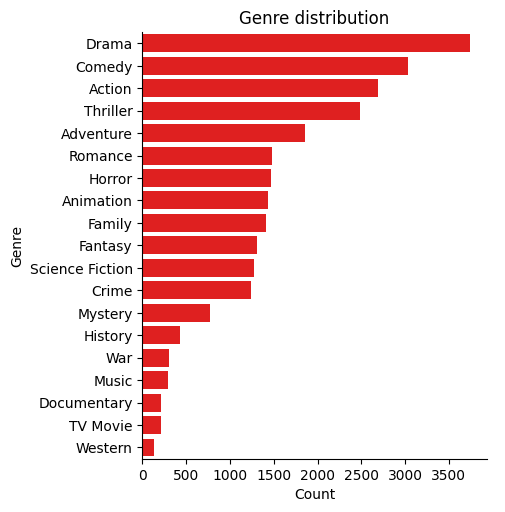

In [37]:
sns.catplot(y='Genre', data=df,kind='count',order=df['Genre'].value_counts().index,color='red')
plt.title('Genre distribution')
plt.xlabel('Count')
plt.ylabel('Genre')

## Q2  What genres has highest votes 

Text(0, 0.5, 'Genre')

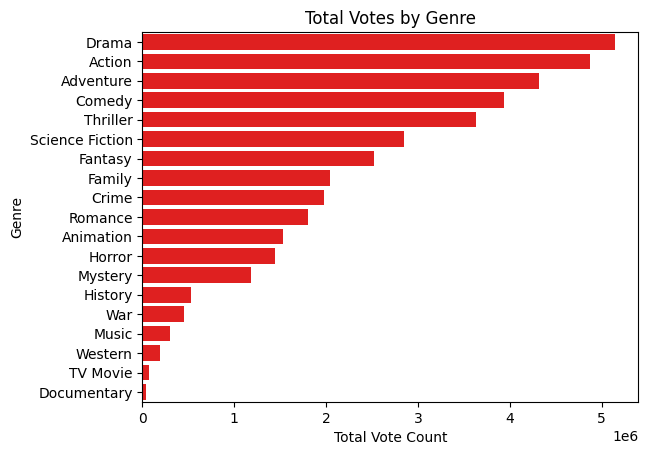

In [61]:
vote_count = df.groupby('Genre')['Vote_Count'].sum().sort_values(ascending=False)
sns.barplot(x=vote_count.values, y=vote_count.index,color='red')
plt.title('Total Votes by Genre')
plt.xlabel('Total Vote Count')
plt.ylabel('Genre')

## 🔥 Popularity Analysis

Popularity scores indicate audience interest and engagement.

We identify:

- The most popular movie in the dataset
- The least popular movie
- Their corresponding genres

This helps understand extremes in audience reception.

## Q3 What movie got the highest popularity ? what's its genre ?

In [ ]:
df[df['Popularity'] == df['Popularity'].max()][['Title','Genre']].reset_index(drop=True)

,Title,Genre
0,Spider-Man: No Way Home,Action
1,Spider-Man: No Way Home,Adventure
2,Spider-Man: No Way Home,Science Fiction


## Q4  What movie got the lowest popularity? what's its genre?

In [52]:
df[df['Popularity'] == df['Popularity'].min()][['Title','Genre']].reset_index(drop=True)

,Title,Genre
0,The United States vs. Billie Holiday,Music
1,The United States vs. Billie Holiday,Drama
2,The United States vs. Billie Holiday,History
3,Threads,War
4,Threads,Drama
5,Threads,Science Fiction


## Q5 Which year has the most filmmed movies?

## 📈 Movie Release Trends Over Time

This analysis examines how movie releases are distributed across years.

Identifying peak production years can reveal industry growth patterns and shifts in content creation.

Text(0.5, 0, 'Release Year')

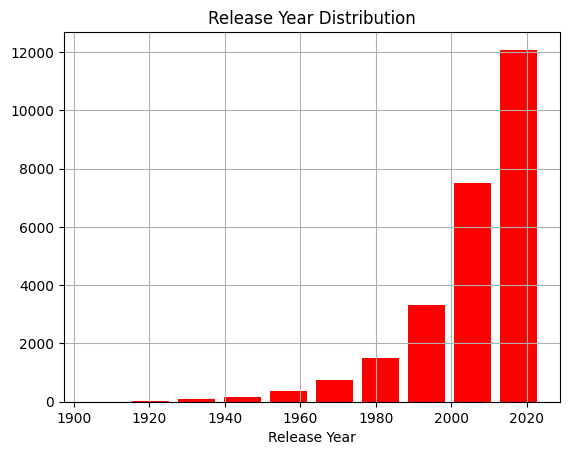

In [62]:
df['Release_Date'].hist(bins=10,color='red',rwidth=0.8)
plt.title('Release Year Distribution')
plt.xlabel('Release Year')

# 🧠 Key Findings & Insights

## 🎭 Genre Insights
- Drama is the most frequent genre in the dataset.
- This suggests strong audience demand and consistent production of drama content.

## ⭐ Rating Insights
- Highly rated movies tend to cluster within specific genres, indicating quality concentration.
- Categorizing vote averages helps identify top-performing content more clearly.

## 🔥 Popularity Insights
- A small number of movies achieve extremely high popularity compared to the rest.
- Popular movies often belong to mainstream genres that appeal to wide audiences.

## 📅 Release Trends
- Movie releases increased significantly in certain years, indicating growth in production.
- Recent years show higher output, possibly due to streaming platform expansion.

---

## 📌 Conclusion

This exploratory analysis demonstrates how movie data can reveal patterns in content production, audience preferences, and popularity trends.

Such insights can support strategic decisions for streaming platforms, including:

- Content acquisition
- Genre investment
- Release planning
- Recommendation systems